# Exploring a single Poisson Change Point detection
Scott Hendrickson (@drskippy)

2014-Nov-27

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.special import xlogy

rng = np.random.default_rng(2014)

Start with simulated statistics.  Poisson model:

$$p(x) = \frac{{e^{ - \lambda } \lambda ^x }}{{x!}}$$

The model is poisson-distributed counts of events per bucket before and after a discontinuous mean change ($\lambda_{before} \rightarrow \lambda_{after}$).

The parameter abRatio is the simple ratio of the parameters,

$$\text{abRatio} = \frac{\lambda_{after}}{\lambda_{before}}$$

Start with a simple exploration where we model a single change point over and over to see how the distribution before and after the change can be compared from a statistical distribution point of view. We will look at 2,000 change point simulations and compare before and after distributions for a range starting value of $\lambda_i = 4$ and a range of final $4 \le \lambda_f < 20$.

In [2]:
sample_size = 2000
starting_lambda = 4.0
lambda_range = 16

Generate a range of changes to explore with the following code. For each $\lambda_f$:
- `count_diff`: one count after the change minus one count before it, `sample_size` times
- `count`: the pooled counts, half drawn before the change and half after

In [3]:
after = starting_lambda + np.arange(lambda_range)  # lambda_f for each scenario
half = sample_size // 2
df = pd.DataFrame({
    "abRatio": np.repeat(after / starting_lambda, sample_size),
    "count_diff": (rng.poisson(after[:, None], (lambda_range, sample_size))
                   - rng.poisson(starting_lambda, (lambda_range, sample_size))).ravel(),
    "count": np.concatenate([rng.poisson(starting_lambda, (lambda_range, half)),
                             rng.poisson(after[:, None], (lambda_range, half))], axis=1).ravel(),
})

In terms of abRatio, the separation of the before and after peaks of the count distribution give us an intuitive sense of how easy it will be to measure the difference between the average before and after the change.  The larger the change, the more distance between the peaks of the before and after distributions. For small values of abRatio, the overall distribution of points before and after the change point is spread slightly. For larger values of abRatio, the peaks become cleanly distinguished.

The plots below show the progression of abRatio's over the range described above.

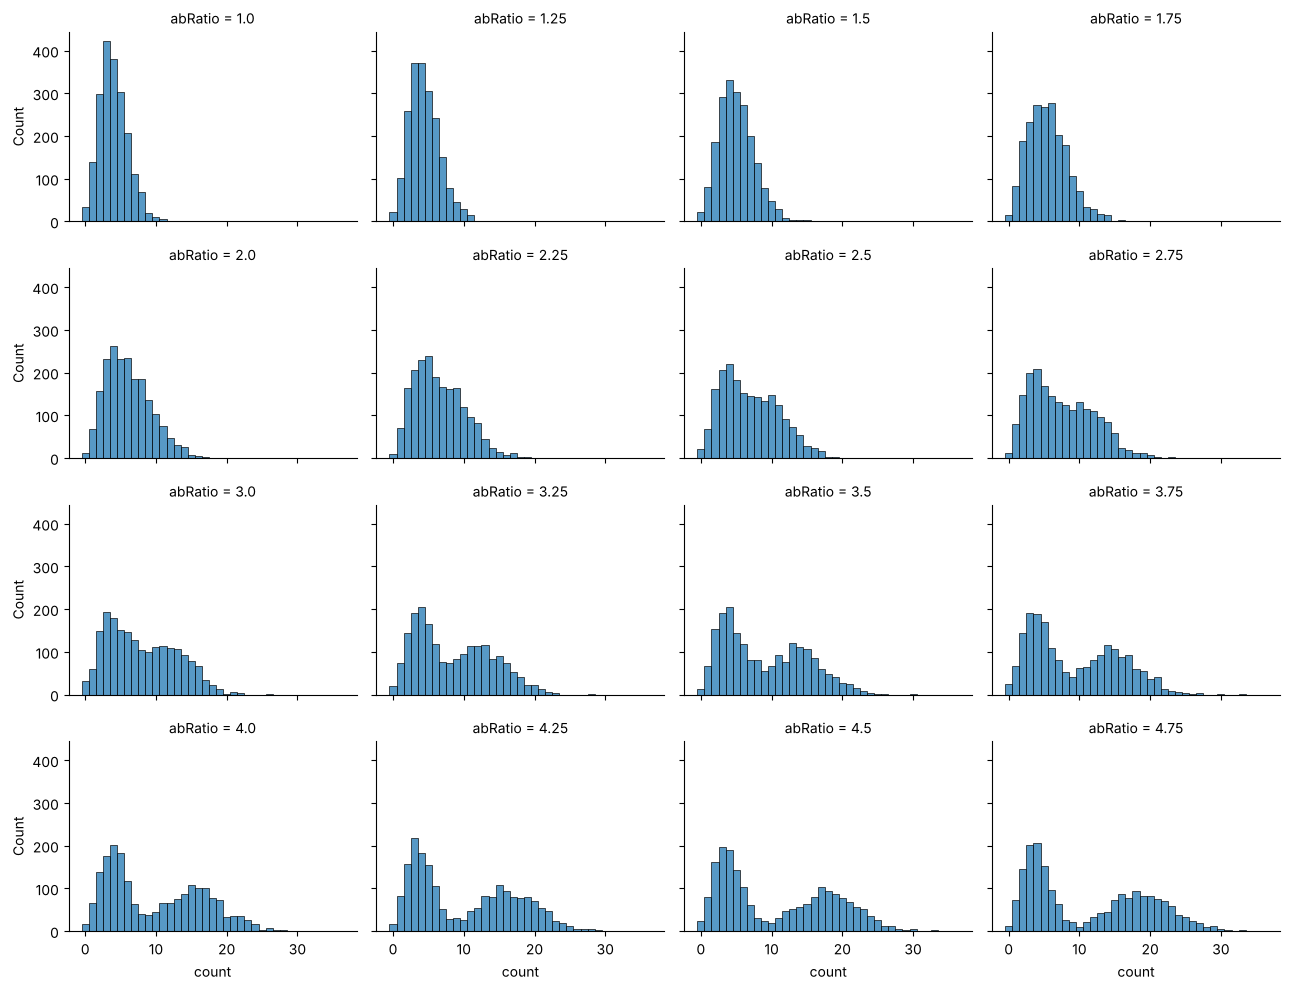

In [4]:
g = sns.displot(df, x="count", col="abRatio", col_wrap=4, discrete=True, height=2.5, aspect=1.3)
g.set_titles("abRatio = {col_name}")
plt.show()

As the ratio of the change increases, the mid-section of the tail gets fatter until the peaks of the individual distributions become increasingly distinct.

What does the distribution of the ${difference}$ of the before and after time series look like?

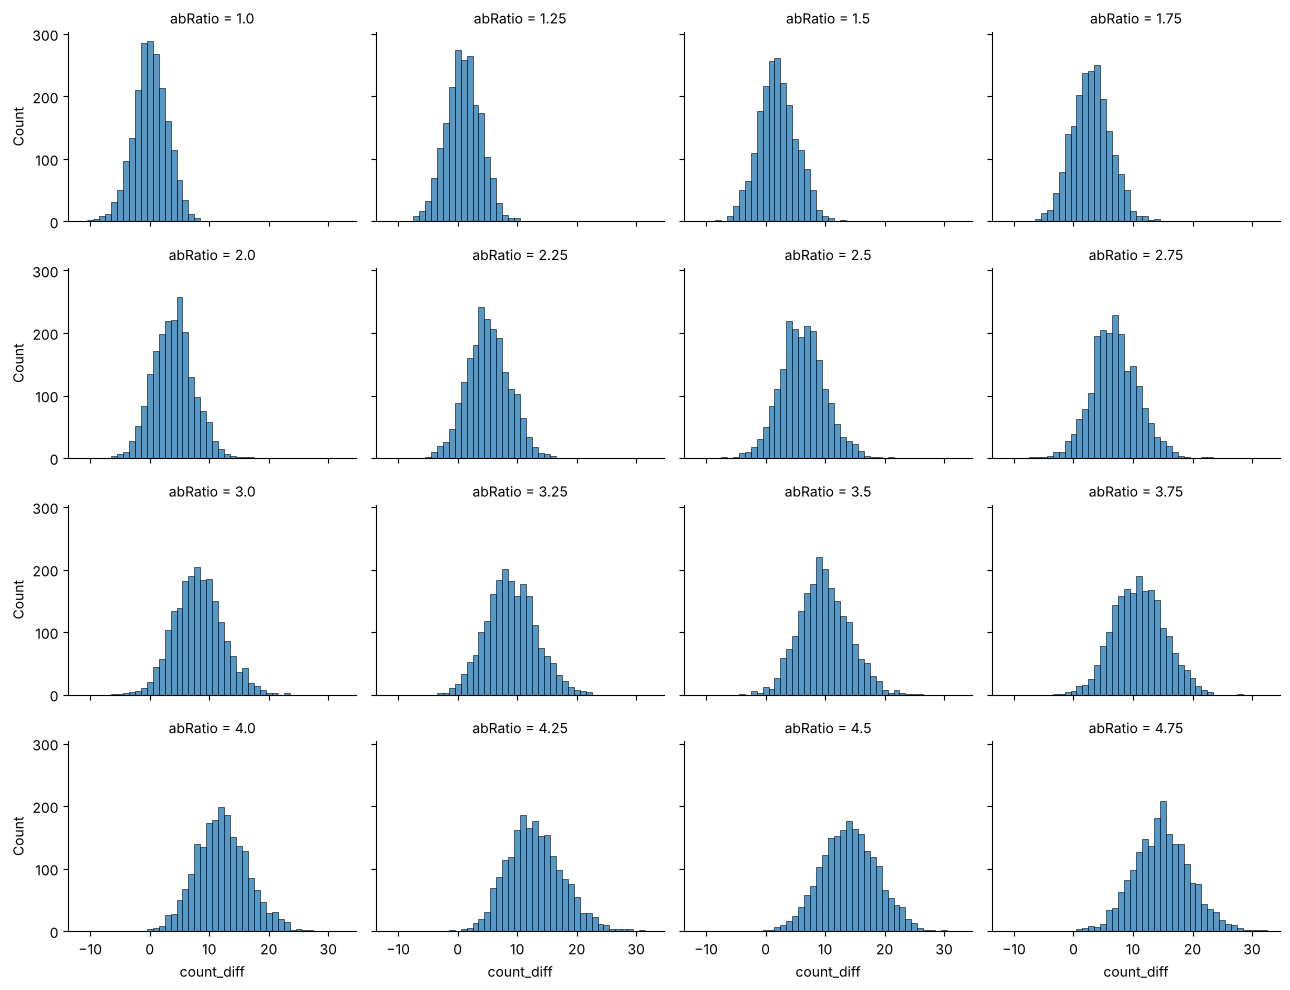

In [5]:
g = sns.displot(df, x="count_diff", col="abRatio", col_wrap=4, discrete=True, height=2.5, aspect=1.3)
g.set_titles("abRatio = {col_name}")
plt.show()

In general, we are looking for signal, i.e., the difference is greater than zero for an increase, or less than zero for a decrease.

To illustrate an intuitive approach to signal detection, look at the fraction of the output where the difference is above zero. The fraction of times the measured difference is greater than zero when there is a real change in $\lambda$ hits 99% when $abRatio>3.5$.

Hardly intuitively, the distribution of the difference of two poisson distributions is a Skellam distribution! Our simple simulation matches the Skellam prediction $P(\text{diff} > 0) = 1 - F_\text{Skellam}(0; \lambda_f, \lambda_i)$ closely.

         Simulation  Skellam
abRatio                     
1.00         0.4385   0.4283
1.25         0.5530   0.5649
1.50         0.6720   0.6820
1.75         0.7735   0.7756
2.00         0.8425   0.8465
2.25         0.9040   0.8978
2.50         0.9415   0.9335
2.75         0.9545   0.9577
3.00         0.9785   0.9736
3.25         0.9835   0.9838
3.50         0.9900   0.9902
3.75         0.9945   0.9942
4.00         0.9985   0.9966
4.25         0.9995   0.9980
4.50         0.9995   0.9989
4.75         1.0000   0.9994


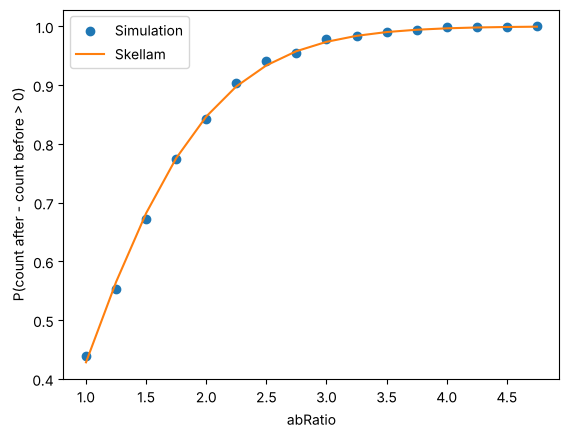

In [6]:
sk = pd.DataFrame({
    "Simulation": (df["count_diff"] > 0).groupby(df["abRatio"]).mean(),
    "Skellam": stats.skellam.sf(0, after, starting_lambda),
})
print(sk.round(4))
ax = sk.plot(style=["o", "-"])
ax.set_ylabel("P(count after - count before > 0)")
plt.show()

## It is easy to build a very naive likelihood change point model

This is helpful to see how this sort of model might work. Don't use this simple model for a real detection algorithm!

The model comes from calculating $P(\lambda_0 \rightarrow \lambda_f) = \Pi_i P(x_i|\lambda_0) \Pi_j P(x_j|\lambda_f)$ for the i points before and the j points after the change point. Working with log likelihood turns these products of probabilities into sums. Plugging in the maximum likelihood rates $\hat\lambda_0 = S_n / n$ and $\hat\lambda_f = S_m / m$ (sums $S$ of the $n$ points before and $m$ points after) and dropping terms that don't depend on the split gives

$$\ell = S_n \log\frac{S_n}{n} + S_m \log\frac{S_m}{m} - \sum_k x_k \log x_k$$

In [7]:
def log_like(windows, n):
    """Split log likelihood for each row of `windows`, split after the first n points."""
    m = windows.shape[-1] - n
    sn = windows[..., :n].sum(axis=-1)
    sm = windows[..., n:].sum(axis=-1)
    return xlogy(sn, sn / n) + xlogy(sm, sm / m) - xlogy(windows, windows).sum(axis=-1)

Let's try an example: Make a time series with a some $\lambda$ changes.

In [8]:
segment = 40
b, a = 10, 30
data = rng.poisson(np.repeat([b, a, b, 2 * a], segment))

Calculate our simple signal on the time series we created: at each time, the split likelihood of the previous
`n_backward + n_forward` points, split `n_forward` points from the end.

In [9]:
n_backward, n_forward = 8, 2
window = n_backward + n_forward
signal = np.zeros(len(data))
signal[window:] = log_like(np.lib.stride_tricks.sliding_window_view(data, window)[:-1], n_backward)

Plot the time series and signal.  With some care and refinement, it seems clear this idea can be used to detect mean shifts.

To use a real Python package, see [bayesian_changepoint_detection](https://github.com/hildensia/bayesian_changepoint_detection) or [ruptures](https://centre-borelli.github.io/ruptures-docs/).

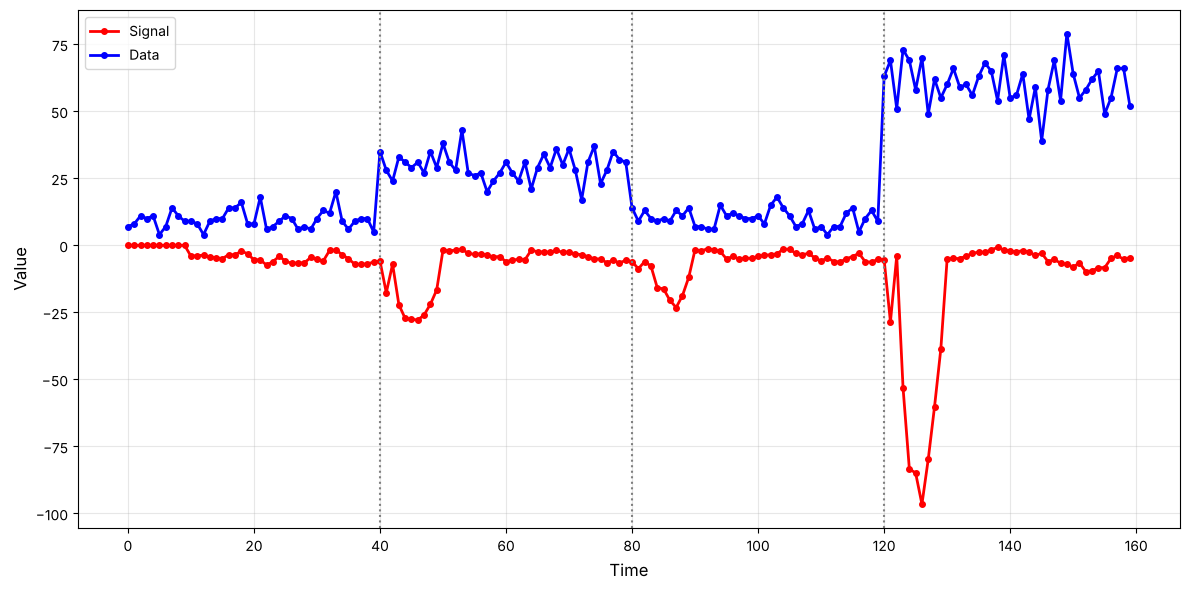

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(signal, color="red", marker="o", lw=2, ms=4, label="Signal")
ax.plot(data, color="blue", marker="o", lw=2, ms=4, label="Data")
for change in segment * np.arange(1, 4):
    ax.axvline(change, color="grey", ls=":")
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()